# Laboratorio 5.
## Clasificación de tweets usando minería de texto

Belén Monterroso 231497 

Melisa Mendizabal 23778 

Renato Rojas 23813 


Utilice el dataset Natural Language Processing with Disaster Tweets de Kaggle. Debe hacer un análisis exploratorio para entender mejor los datos, sabiendo que el objetivo final clasificar si un tweet se refiere a un desastre real o no. Genere un informe con las explicaciones de los pasos que llevó a cabo y los resultados obtenidos. Recuerde que la investigación debe ser reproducible por lo que debe guardar el código que ha utilizado para resolver los ejercicios y/o cada uno de los pasos llevados a cabo si utiliza una herramienta visual. Incluya una nube de palabras que le ayude a detectar las que más se repiten.

In [28]:
import pandas as pd

# 1. Descargue el archivo train.csv


In [29]:
train_path = r'train.csv'
test_path = r'test.csv'
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# 2. Cargue los archivos de datos a R o a Python, dependiendo de con qué trabaje.

In [30]:
train.head(10)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1


In [31]:
test.head(10)

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
5,12,NaN,NaN,We're shaking...It's an earthquake
6,21,NaN,NaN,They'd probably still show more life than Arse...
7,22,NaN,NaN,Hey! How are you?
8,27,NaN,NaN,What a nice hat?
9,29,NaN,NaN,Fuck off!


In [32]:
print(train.shape)
print(train.columns)
print(train.isnull().sum())
print(test.shape)
print(test.columns)
print(test.isnull().sum())

(7613, 5)
Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64
(3263, 4)
Index(['id', 'keyword', 'location', 'text'], dtype='object')
id             0
keyword       26
location    1105
text           0
dtype: int64


## 3. Limpie y preprocese los datos. Describa de forma detallada las actividades de preprocesamiento que llevó a cabo.


### 3.1 Convertir el texto a mayúsculas o a minúsculas


In [33]:
train['text_clean'] = train['text'].str.lower()
test['text_clean'] = test['text'].str.lower()

# Verificamos el cambio
print(train[['text', 'text_clean']].head(5))

                                                text  \
0  Our Deeds are the Reason of this #earthquake M...   
1             Forest fire near La Ronge Sask. Canada   
2  All residents asked to 'shelter in place' are ...   
3  13,000 people receive #wildfires evacuation or...   
4  Just got sent this photo from Ruby #Alaska as ...   

                                          text_clean  
0  our deeds are the reason of this #earthquake m...  
1             forest fire near la ronge sask. canada  
2  all residents asked to 'shelter in place' are ...  
3  13,000 people receive #wildfires evacuation or...  
4  just got sent this photo from ruby #alaska as ...  


### 3.2 Quitar las url

In [34]:
import re

def quitar_urls(texto):
    return re.sub(r'http\S+|www\.\S+', '', texto)

train['text_clean'] = train['text_clean'].apply(quitar_urls)
test['text_clean'] = test['text_clean'].apply(quitar_urls)
print(train[['text_clean']].head(5))

                                          text_clean
0  our deeds are the reason of this #earthquake m...
1             forest fire near la ronge sask. canada
2  all residents asked to 'shelter in place' are ...
3  13,000 people receive #wildfires evacuation or...
4  just got sent this photo from ruby #alaska as ...


### 3.3 Quitar los caracteres especiales que aparecen como “#”,”@” o los apóstrofes.

In [35]:
def quitar_arroba_hashtag(texto):
    texto = re.sub(r'@\w+', '', texto)      # elimina menciones completas (@usuario)
    texto = re.sub(r'#', '', texto)         
    return texto

train['text_clean'] = train['text_clean'].apply(quitar_arroba_hashtag)
test['text_clean'] = test['text_clean'].apply(quitar_arroba_hashtag)
print(train[['text_clean']].head(5))

                                          text_clean
0  our deeds are the reason of this earthquake ma...
1             forest fire near la ronge sask. canada
2  all residents asked to 'shelter in place' are ...
3  13,000 people receive wildfires evacuation ord...
4  just got sent this photo from ruby alaska as s...


### 3.4 Revisar si hay emoticones y quitarlos

In [36]:
def quitar_emojis(texto):
    patron_emoji = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticones
        "\U0001F300-\U0001F5FF"  # símbolos y pictogramas
        "\U0001F680-\U0001F6FF"  # transporte y mapas
        "\U0001F1E0-\U0001F1FF"  # banderas
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "]+", flags=re.UNICODE
    )
    return patron_emoji.sub('', texto)

# Primero revisamos si hay tweets con emojis
tiene_emoji = train['text_clean'].apply(lambda t: bool(re.search(r'[\U0001F300-\U0001FAFF]', t)))
print("Tweets con emoji encontrados:", tiene_emoji.sum())
print(train.loc[tiene_emoji, 'text_clean'].head(5))

# Ahora los quitamos
train['text_clean'] = train['text_clean'].apply(quitar_emojis)
test['text_clean'] = test['text_clean'].apply(quitar_emojis)

Tweets con emoji encontrados: 0
Series([], Name: text_clean, dtype: object)


### 3.5 Quitar los signos de puntuación

In [37]:
import string

def quitar_puntuacion(texto):
    return texto.translate(str.maketrans('', '', string.punctuation))

train['text_clean'] = train['text_clean'].apply(quitar_puntuacion)
test['text_clean'] = test['text_clean'].apply(quitar_puntuacion)
print(train[['text_clean']].head(5))

                                          text_clean
0  our deeds are the reason of this earthquake ma...
1              forest fire near la ronge sask canada
2  all residents asked to shelter in place are be...
3  13000 people receive wildfires evacuation orde...
4  just got sent this photo from ruby alaska as s...


### 3.6 Quitar números

In [38]:
# Primero revisamos qué tan frecuente es "911" en tweets de desastre vs no desastre
print("Tweets desastre con '911':", train[train['target']==1]['text_clean'].str.contains(r'\b911\b').sum())
print("Tweets NO desastre con '911':", train[train['target']==0]['text_clean'].str.contains(r'\b911\b').sum())

def quitar_numeros(texto, conservar_911=True):
    if conservar_911:
        # Protegemos temporalmente el 911
        texto = texto.replace('911', 'EMERGENCIA911TOKEN')
    texto = re.sub(r'\d+', '', texto)
    if conservar_911:
        texto = texto.replace('EMERGENCIA911TOKEN', '911')
    return texto

train['text_clean'] = train['text_clean'].apply(quitar_numeros)
test['text_clean'] = test['text_clean'].apply(quitar_numeros)
print(train[['text_clean']].head(5))

Tweets desastre con '911': 7
Tweets NO desastre con '911': 3
                                          text_clean
0  our deeds are the reason of this earthquake ma...
1              forest fire near la ronge sask canada
2  all residents asked to shelter in place are be...
3   people receive wildfires evacuation orders in...
4  just got sent this photo from ruby alaska as s...


### 3.7 Quitar stopwords (artículos, preposiciones, conjunciones)

In [39]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def quitar_stopwords(texto):
    palabras = texto.split()
    palabras_filtradas = [p for p in palabras if p not in stop_words]
    return ' '.join(palabras_filtradas)

train['text_clean'] = train['text_clean'].apply(quitar_stopwords)
test['text_clean'] = test['text_clean'].apply(quitar_stopwords)
print(train[['text', 'text_clean']].head(10))

                                                text  \
0  Our Deeds are the Reason of this #earthquake M...   
1             Forest fire near La Ronge Sask. Canada   
2  All residents asked to 'shelter in place' are ...   
3  13,000 people receive #wildfires evacuation or...   
4  Just got sent this photo from Ruby #Alaska as ...   
5  #RockyFire Update => California Hwy. 20 closed...   
6  #flood #disaster Heavy rain causes flash flood...   
7  I'm on top of the hill and I can see a fire in...   
8  There's an emergency evacuation happening now ...   
9  I'm afraid that the tornado is coming to our a...   

                                          text_clean  
0       deeds reason earthquake may allah forgive us  
1              forest fire near la ronge sask canada  
2  residents asked shelter place notified officer...  
3  people receive wildfires evacuation orders cal...  
4  got sent photo ruby alaska smoke wildfires pou...  
5  rockyfire update california hwy closed directi... 

[nltk_data] Downloading package stopwords to C:\Users\Usuario
[nltk_data]     Preinstalado\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 3.8 Quitar espacios extra que quedan tras las limpiezas

In [40]:
train['text_clean'] = train['text_clean'].str.strip().str.replace(r'\s+', ' ', regex=True)
test['text_clean'] = test['text_clean'].str.strip().str.replace(r'\s+', ' ', regex=True)
print(train[['text_clean']].head(10))

                                          text_clean
0       deeds reason earthquake may allah forgive us
1              forest fire near la ronge sask canada
2  residents asked shelter place notified officer...
3  people receive wildfires evacuation orders cal...
4  got sent photo ruby alaska smoke wildfires pou...
5  rockyfire update california hwy closed directi...
6  flood disaster heavy rain causes flash floodin...
7                         im top hill see fire woods
8  theres emergency evacuation happening building...
9                      im afraid tornado coming area


### 3.9 Decodificar entidades HTML (&, <, etc.)

In [41]:
import html

train['text_clean'] = train['text_clean'].apply(html.unescape)
test['text_clean'] = test['text_clean'].apply(html.unescape)

# Verificamos si había casos
print(train[train['text'].str.contains('&amp;|&lt;|&gt;', regex=True, na=False)][['text']].head(5))

                                                 text
62  Rene Ablaze &amp; Jacinta - Secret 2k13 (Falle...
64  #NowPlaying: Rene Ablaze &amp; Ian Buff - Magn...
67  'I can't have kids cuz I got in a bicycle acci...
70  http://t.co/GKYe6gjTk5 Had a #personalinjury a...
83  #TruckCrash Overturns On #FortWorth Interstate...


### 3.10 Emoticones hechos con puntuación (:), :(, :D, etc.)

In [42]:
# Revisamos si hay emoticones de texto antes de quitar puntuación
patron_emoticon = r'[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]'
tiene_emoticon = train['text'].str.contains(patron_emoticon, regex=True)
print("Tweets con emoticones de texto:", tiene_emoticon.sum())
print(train.loc[tiene_emoticon, 'text'].head(5))

Tweets con emoticones de texto: 4059
21                                    London is cool ;)
28                                            Cooool :)
31    @bbcmtd Wholesale Markets ablaze http://t.co/l...
32    We always try to bring the heavy. #metal #RT h...
33    #AFRICANBAZE: Breaking news:Nigeria flag set a...
Name: text, dtype: object


### 3.11 Normalizar letras repetidas ("fiiiire", "hooot")

In [43]:
def normalizar_repeticiones(texto):
    return re.sub(r'(.)\1{2,}', r'\1\1', texto)  # deja máximo 2 repeticiones

train['text_clean'] = train['text_clean'].apply(normalizar_repeticiones)
test['text_clean'] = test['text_clean'].apply(normalizar_repeticiones)
print(train[['text_clean']].head(5))

                                          text_clean
0       deeds reason earthquake may allah forgive us
1              forest fire near la ronge sask canada
2  residents asked shelter place notified officer...
3  people receive wildfires evacuation orders cal...
4  got sent photo ruby alaska smoke wildfires pou...


### 3.12 Quitar palabras de una sola letra sueltas (residuos de la limpieza)

Después de quitar apóstrofes, "I'm" se vuelve "im" (bien), pero a veces quedan letras sueltas tipo "s" de posesivos mal cortados

In [44]:
def quitar_letras_sueltas(texto):
    return ' '.join([p for p in texto.split() if len(p) > 1])

train['text_clean'] = train['text_clean'].apply(quitar_letras_sueltas)
test['text_clean'] = test['text_clean'].apply(quitar_letras_sueltas)

### 3.13 Stemming o lematización 

Reduce palabras a su raíz (running, runs, ran a run), lo cual ayuda mucho a la frecuencia de palabras.

In [45]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Usuario
[nltk_data]     Preinstalado\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [46]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')  # necesario para el POS tagging
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

def obtener_pos_wordnet(tag):
    #Convierte el tag de POS de nltk al formato que espera WordNet
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # por default se asume sustantivo

def aplicar_lematizacion(texto):
    palabras = texto.split()
    tags = pos_tag(palabras)
    lematizadas = [lemmatizer.lemmatize(palabra, obtener_pos_wordnet(tag)) for palabra, tag in tags]
    return ' '.join(lematizadas)

train['text_clean'] = train['text_clean'].apply(aplicar_lematizacion)
test['text_clean'] = test['text_clean'].apply(aplicar_lematizacion)
print(train[['text', 'text_clean']].head(10))

[nltk_data] Downloading package wordnet to C:\Users\Usuario
[nltk_data]     Preinstalado\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Usuario
[nltk_data]     Preinstalado\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Usuario
[nltk_data]     Preinstalado\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


                                                text  \
0  Our Deeds are the Reason of this #earthquake M...   
1             Forest fire near La Ronge Sask. Canada   
2  All residents asked to 'shelter in place' are ...   
3  13,000 people receive #wildfires evacuation or...   
4  Just got sent this photo from Ruby #Alaska as ...   
5  #RockyFire Update => California Hwy. 20 closed...   
6  #flood #disaster Heavy rain causes flash flood...   
7  I'm on top of the hill and I can see a fire in...   
8  There's an emergency evacuation happening now ...   
9  I'm afraid that the tornado is coming to our a...   

                                          text_clean  
0         deed reason earthquake may allah forgive u  
1              forest fire near la ronge sask canada  
2  resident ask shelter place notify officer evac...  
3  people receive wildfire evacuation order calif...  
4  get sent photo ruby alaska smoke wildfires pou...  
5  rockyfire update california hwy close directio... 

### 3.14 Revisar duplicados y filas vacías tras la limpieza

In [47]:
# Duplicados exactos en el texto original
print("Tweets duplicados:", train.duplicated(subset='text').sum())

# Tweets que quedaron vacíos después de tanta limpieza
vacios = train[train['text_clean'].str.strip() == '']
print("Tweets que quedaron vacíos tras limpieza:", len(vacios))
print(vacios[['text']])

Tweets duplicados: 110
Tweets que quedaron vacíos tras limpieza: 0
Empty DataFrame
Columns: [text]
Index: []


## 4. Obtenga la frecuencia de las palabras tanto de los tweets de desastres como de los que no. ¿Qué palabras cree que le servirán para hacer un mejor modelo de clasificación?¿vale la pena explorar bigramas o trigramas para analizar contexto?

### 4.1 Frecuencia de palabras en tweets de desastre

In [48]:
from collections import Counter

palabras_desastre = ' '.join(train[train['target']==1]['text_clean']).split()
frecuencia_desastre = Counter(palabras_desastre)

print("Top 20 palabras más frecuentes en tweets de DESASTRE:")
for palabra, freq in frecuencia_desastre.most_common(20):
    print(f"{palabra}: {freq}")

Top 20 palabras más frecuentes en tweets de DESASTRE:
fire: 268
kill: 155
bomb: 141
news: 138
via: 121
get: 118
disaster: 118
california: 113
flood: 113
crash: 111
suicide: 110
police: 107
amp: 107
people: 106
family: 105
train: 102
home: 101
attack: 99
like: 99
say: 93


### 4.2 Frecuencia de palabras en tweets NO de desastre

In [49]:
palabras_no_desastre = ' '.join(train[train['target']==0]['text_clean']).split()
frecuencia_no_desastre = Counter(palabras_no_desastre)

print("Top 20 palabras más frecuentes en tweets NO desastre:")
for palabra, freq in frecuencia_no_desastre.most_common(20):
    print(f"{palabra}: {freq}")

Top 20 palabras más frecuentes en tweets NO desastre:
get: 305
like: 290
im: 243
go: 194
amp: 193
new: 172
dont: 141
one: 136
make: 129
body: 116
see: 114
love: 109
come: 107
say: 106
time: 105
bag: 105
video: 101
know: 100
via: 99
day: 97


### 4.3 Identificar palabras "distintivas" de cada clase

In [50]:
set_desastre = set(dict(frecuencia_desastre.most_common(50)).keys())
set_no_desastre = set(dict(frecuencia_no_desastre.most_common(50)).keys())

solo_desastre = set_desastre - set_no_desastre
solo_no_desastre = set_no_desastre - set_desastre

print("Palabras que SOLO aparecen entre las top 50 de DESASTRE:")
print(solo_desastre)
print("\nPalabras que SOLO aparecen entre las top 50 de NO DESASTRE:")
print(solo_no_desastre)

Palabras que SOLO aparecen entre las top 50 de DESASTRE:
{'kill', 'building', 'collapse', 'flood', 'accident', 'storm', 'report', 'home', 'crash', 'california', 'northern', 'family', 'police', 'two', 'attack', 'bomber', 'train', 'mh', 'dead', 'war', 'disaster', 'car', 'wildfire', 'news', 'hiroshima', 'suicide', 'cause', 'death', 'evacuate', 'watch', 'pm', 'nuclear', 'bomb'}

Palabras que SOLO aparecen entre las top 50 de NO DESASTRE:
{'bag', 'full', 'come', 'let', 'take', 'rt', 'would', 'scream', 'dont', 'make', 'good', 'work', 'know', 'drown', 'man', 'feel', 'body', 'want', 'need', 'lol', 'think', 'see', 'look', 'world', 'day', 'panic', 'back', 'im', 'life', 'love', 'cant', 'wreck', 'fuck'}


### Frecuencia relativa (proporción, no solo conteo)

In [51]:
n_desastre = train[train['target']==1].shape[0]
n_no_desastre = train[train['target']==0].shape[0]

print(f"Total tweets desastre: {n_desastre}, no desastre: {n_no_desastre}\n")

print("Top 15 palabras por FRECUENCIA RELATIVA en desastre:")
for palabra, freq in frecuencia_desastre.most_common(15):
    print(f"{palabra}: {freq/n_desastre:.3%}")

Total tweets desastre: 3271, no desastre: 4342

Top 15 palabras por FRECUENCIA RELATIVA en desastre:
fire: 8.193%
kill: 4.739%
bomb: 4.311%
news: 4.219%
via: 3.699%
get: 3.607%
disaster: 3.607%
california: 3.455%
flood: 3.455%
crash: 3.393%
suicide: 3.363%
police: 3.271%
amp: 3.271%
people: 3.241%
family: 3.210%


### Bigramas y trigramas

In [52]:
from nltk import bigrams, trigrams

def obtener_ngramas(lista_textos, n=2, top=15):
    todas_palabras = ' '.join(lista_textos).split()
    if n == 2:
        ngramas = list(bigrams(todas_palabras))
    else:
        ngramas = list(trigrams(todas_palabras))
    return Counter(ngramas).most_common(top)

print("Top bigramas en tweets de DESASTRE:")
for ng, freq in obtener_ngramas(train[train['target']==1]['text_clean'], n=2):
    print(f"{ng}: {freq}")

print("\nTop bigramas en tweets NO desastre:")
for ng, freq in obtener_ngramas(train[train['target']==0]['text_clean'], n=2):
    print(f"{ng}: {freq}")

print("\nTop trigramas en tweets de DESASTRE:")
for ng, freq in obtener_ngramas(train[train['target']==1]['text_clean'], n=3):
    print(f"{ng}: {freq}")

Top bigramas en tweets de DESASTRE:
('suicide', 'bomber'): 60
('northern', 'california'): 41
('oil', 'spill'): 38
('california', 'wildfire'): 35
('bomber', 'detonate'): 30
('suicide', 'bomb'): 29
('confirm', 'mh'): 29
('detonate', 'bomb'): 29
('yr', 'old'): 29
('home', 'raze'): 29
('severe', 'thunderstorm'): 28
('mass', 'murder'): 28
('late', 'home'): 28
('raze', 'northern'): 28
('pkk', 'suicide'): 28

Top bigramas en tweets NO desastre:
('body', 'bag'): 67
('cross', 'body'): 38
('look', 'like'): 36
('like', 'video'): 32
('feel', 'like'): 25
('full', 're\x89û'): 25
('full', 'read'): 22
('reddit', 'quarantine'): 21
('content', 'policy'): 20
('emergency', 'service'): 18
('quarantine', 'offensive'): 18
('offensive', 'content'): 18
('pick', 'fan'): 17
('fan', 'army'): 17
('fall', 'cliff'): 17

Top trigramas en tweets de DESASTRE:
('suicide', 'bomber', 'detonate'): 30
('northern', 'california', 'wildfire'): 29
('late', 'home', 'raze'): 28
('home', 'raze', 'northern'): 28
('pkk', 'suicide', 

c:\Users\Usuario Preinstalado\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


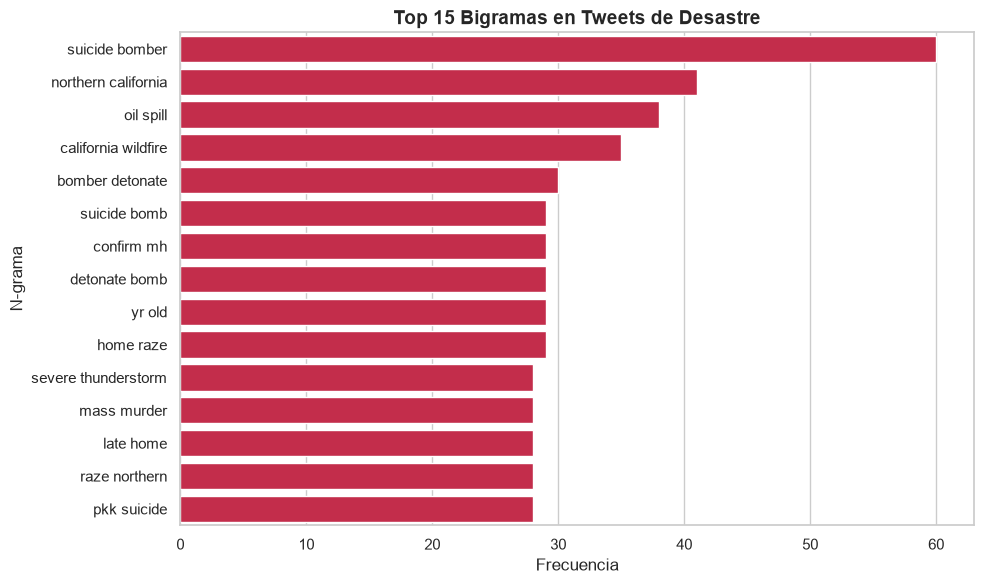

c:\Users\Usuario Preinstalado\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
C:\Users\Usuario Preinstalado\AppData\Local\Temp\ipykernel_5804\2290404137.py:28: UserWarning: Glyph 137 (\x89) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Usuario Preinstalado\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 137 (\x89) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


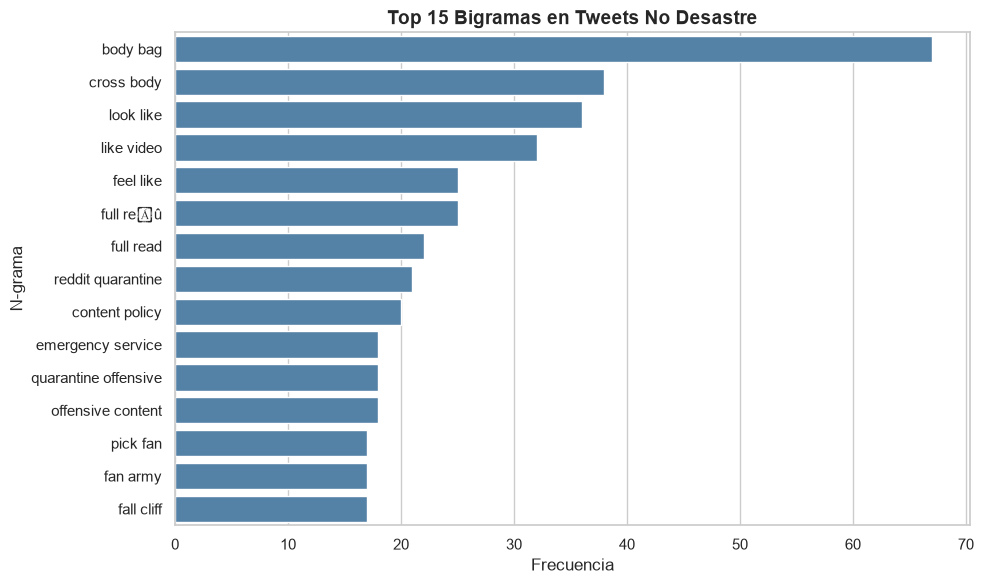

c:\Users\Usuario Preinstalado\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


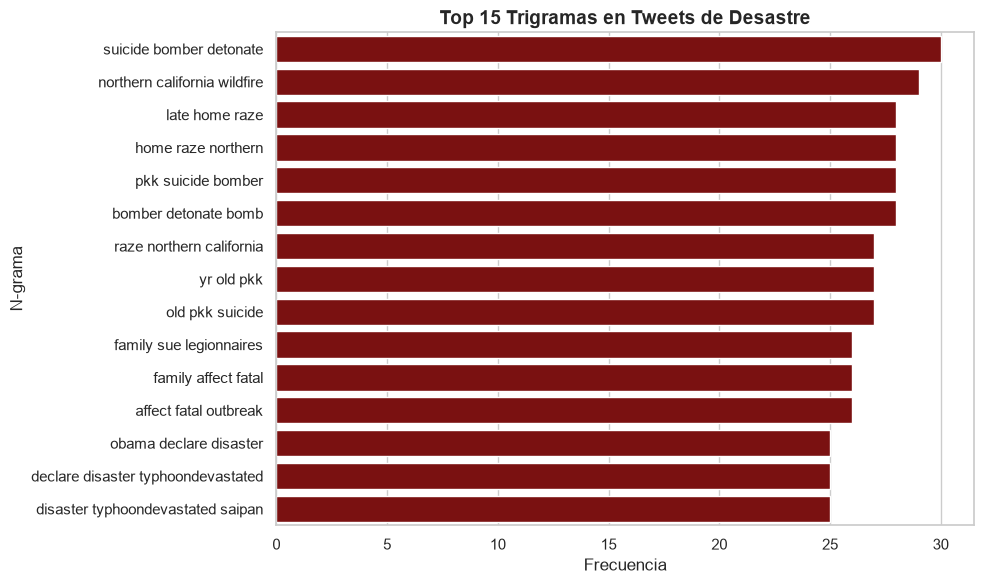

In [53]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from nltk import bigrams, trigrams

# Configuración de estilo
sns.set_theme(style="whitegrid")


# Función para graficar los n-gramas
def graficar_ngramas(
    lista_textos, titulo, n=2, top=15, color="steelblue"
):
    # Obtenemos los n-gramas más frecuentes
    datos = obtener_ngramas(lista_textos, n=n, top=top)

    # Convertimos la tupla de palabras en un solo texto ("palabra1 palabra2")
    etiquetas = [" ".join(grama) for grama, freq in datos]
    frecuencias = [freq for grama, freq in datos]

    # Crear la figura
    plt.figure(figsize=(10, 6))
    sns.barplot(x=frecuencias, y=etiquetas, color=color)

    plt.title(titulo, fontsize=14, fontweight="bold")
    plt.xlabel("Frecuencia", fontsize=12)
    plt.ylabel("N-grama", fontsize=12)
    plt.tight_layout()
    plt.show()


# 1. Bigramas en tweets de DESASTRE
graficar_ngramas(
    train[train["target"] == 1]["text_clean"],
    titulo="Top 15 Bigramas en Tweets de Desastre",
    n=2,
    top=15,
    color="crimson",
)

# 2. Bigramas en tweets NO DESASTRE
graficar_ngramas(
    train[train["target"] == 0]["text_clean"],
    titulo="Top 15 Bigramas en Tweets No Desastre",
    n=2,
    top=15,
    color="steelblue",
)

# 3. Trigramas en tweets de DESASTRE
graficar_ngramas(
    train[train["target"] == 1]["text_clean"],
    titulo="Top 15 Trigramas en Tweets de Desastre",
    n=3,
    top=15,
    color="darkred",
)

### Exportar modelo limpio

In [54]:
train.to_csv("train_clean.csv", index=False)
test.to_csv("test_clean.csv", index=False)

## 5. Análisis exploratorio
### 5.1 Palabra que más se repite en cada categoría

In [55]:
print("Palabra más frecuente en tweets de DESASTRE:")
print(frecuencia_desastre.most_common(1))

print("\nPalabra más frecuente en tweets NO desastre:")
print(frecuencia_no_desastre.most_common(1))

Palabra más frecuente en tweets de DESASTRE:
[('fire', 268)]

Palabra más frecuente en tweets NO desastre:
[('get', 305)]


### 5.2 Nube de palabras (WordCloud)

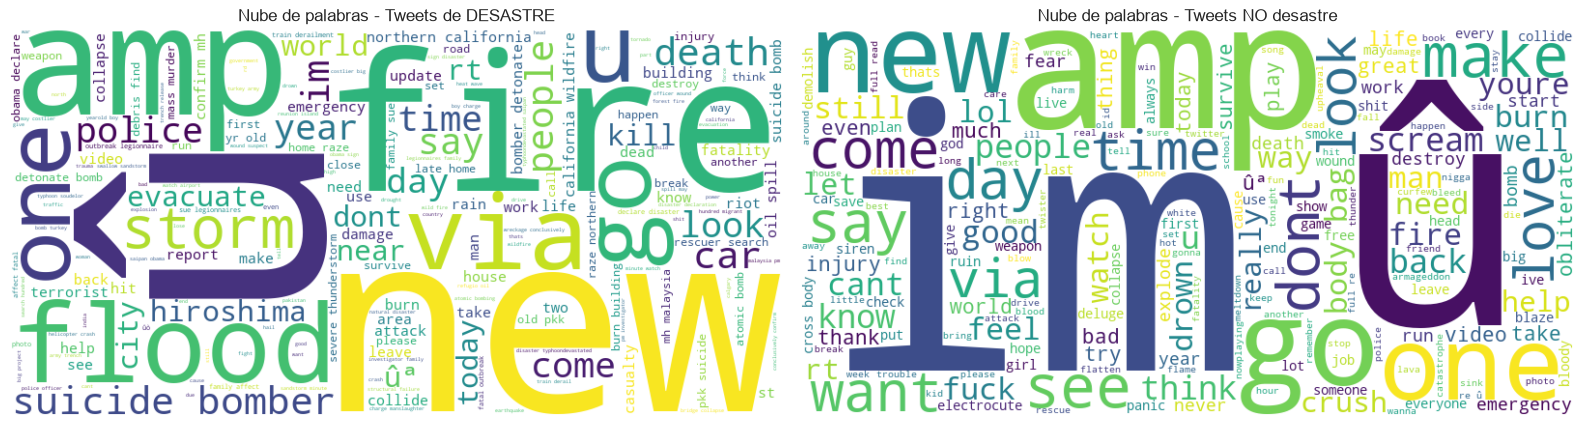

In [56]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texto_desastre = ' '.join(train[train['target']==1]['text_clean'])
texto_no_desastre = ' '.join(train[train['target']==0]['text_clean'])

wc_desastre = WordCloud(width=800, height=400, background_color='white').generate(texto_desastre)
wc_no_desastre = WordCloud(width=800, height=400, background_color='white').generate(texto_no_desastre)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_desastre, interpolation='bilinear')
axes[0].set_title('Nube de palabras - Tweets de DESASTRE')
axes[0].axis('off')

axes[1].imshow(wc_no_desastre, interpolation='bilinear')
axes[1].set_title('Nube de palabras - Tweets NO desastre')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 5.3 Histograma de las palabras más repetidas

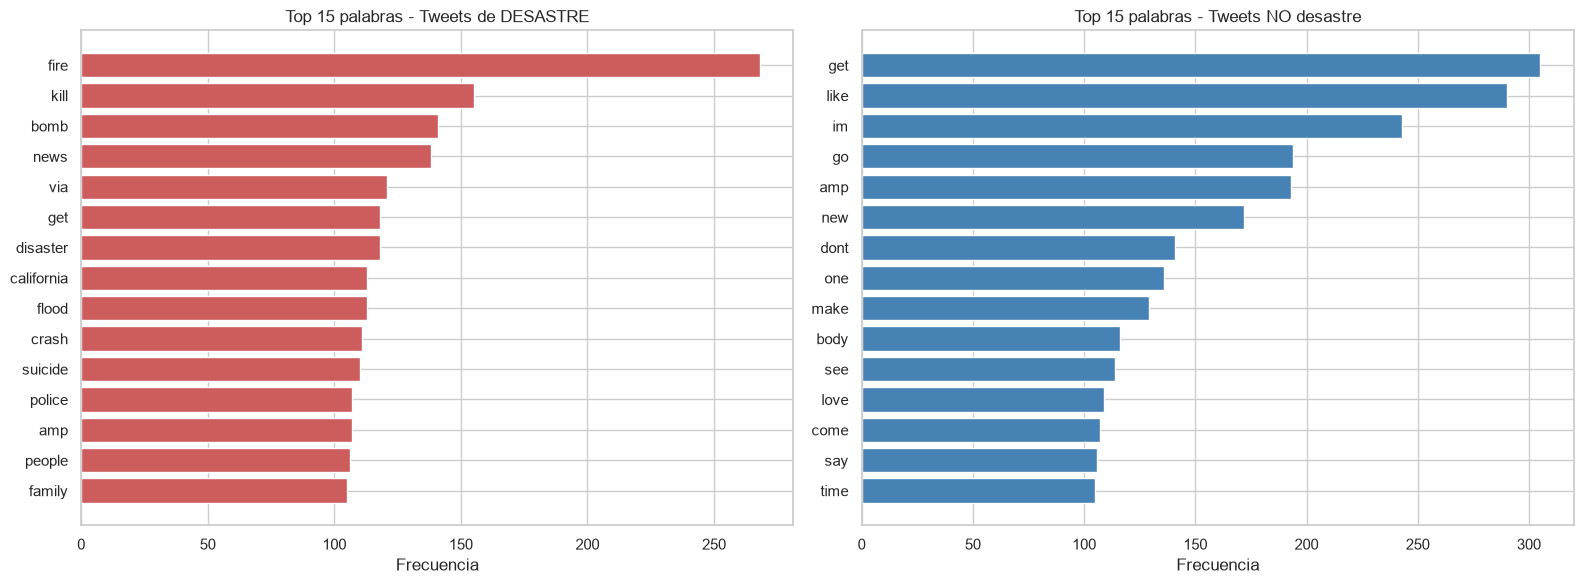

In [57]:
import pandas as pd

top_desastre = pd.DataFrame(frecuencia_desastre.most_common(15), columns=['palabra', 'frecuencia'])
top_no_desastre = pd.DataFrame(frecuencia_no_desastre.most_common(15), columns=['palabra', 'frecuencia'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_desastre['palabra'][::-1], top_desastre['frecuencia'][::-1], color='indianred')
axes[0].set_title('Top 15 palabras - Tweets de DESASTRE')
axes[0].set_xlabel('Frecuencia')

axes[1].barh(top_no_desastre['palabra'][::-1], top_no_desastre['frecuencia'][::-1], color='steelblue')
axes[1].set_title('Top 15 palabras - Tweets NO desastre')
axes[1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

### 5.4 Palabras presentes en ambas categorías

In [58]:
palabras_comunes = set_desastre & set_no_desastre
print(f"Cantidad de palabras comunes entre las top 50 de ambas clases: {len(palabras_comunes)}")
print(palabras_comunes)

# Comparamos su frecuencia relativa en cada clase para ver si están balanceadas o sesgadas
print("\nComparación de frecuencia relativa (palabras comunes):")
for palabra in palabras_comunes:
    freq_d = frecuencia_desastre[palabra] / n_desastre
    freq_nd = frecuencia_no_desastre[palabra] / n_no_desastre
    print(f"{palabra:15s} | desastre: {freq_d:.3%} | no desastre: {freq_nd:.3%}")

Cantidad de palabras comunes entre las top 50 de ambas clases: 17
{'say', 'emergency', 'u', 'like', 'people', 'fire', 'go', 'via', 'year', 'new', 'amp', 'one', 'burn', 'still', 'get', 'video', 'time'}

Comparación de frecuencia relativa (palabras comunes):
say             | desastre: 2.843% | no desastre: 2.441%
emergency       | desastre: 2.323% | no desastre: 1.889%
u               | desastre: 2.568% | no desastre: 1.981%
like            | desastre: 3.027% | no desastre: 6.679%
people          | desastre: 3.241% | no desastre: 2.119%
fire            | desastre: 8.193% | no desastre: 2.073%
go              | desastre: 2.476% | no desastre: 4.468%
via             | desastre: 3.699% | no desastre: 2.280%
year            | desastre: 2.629% | no desastre: 1.474%
new             | desastre: 1.773% | no desastre: 3.961%
amp             | desastre: 3.271% | no desastre: 4.445%
one             | desastre: 2.109% | no desastre: 3.132%
burn            | desastre: 2.201% | no desastre: 1.889%
st

### 5.5 Balance de clases (desastre vs no desastre)

target
0    4342
1    3271
Name: count, dtype: int64


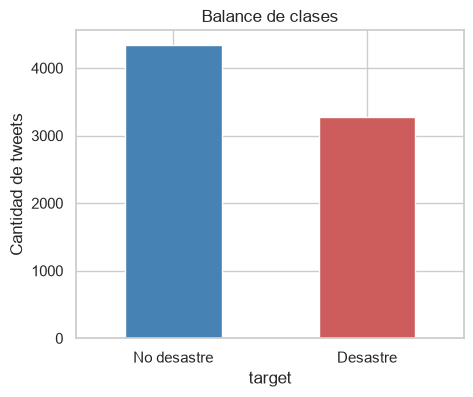

In [59]:
conteo_clases = train['target'].value_counts()
print(conteo_clases)

plt.figure(figsize=(5,4))
conteo_clases.plot(kind='bar', color=['steelblue','indianred'])
plt.xticks([0,1], ['No desastre', 'Desastre'], rotation=0)
plt.title('Balance de clases')
plt.ylabel('Cantidad de tweets')
plt.show()

### 5.6 Distribución de la longitud de los tweets (en palabras y en caracteres)

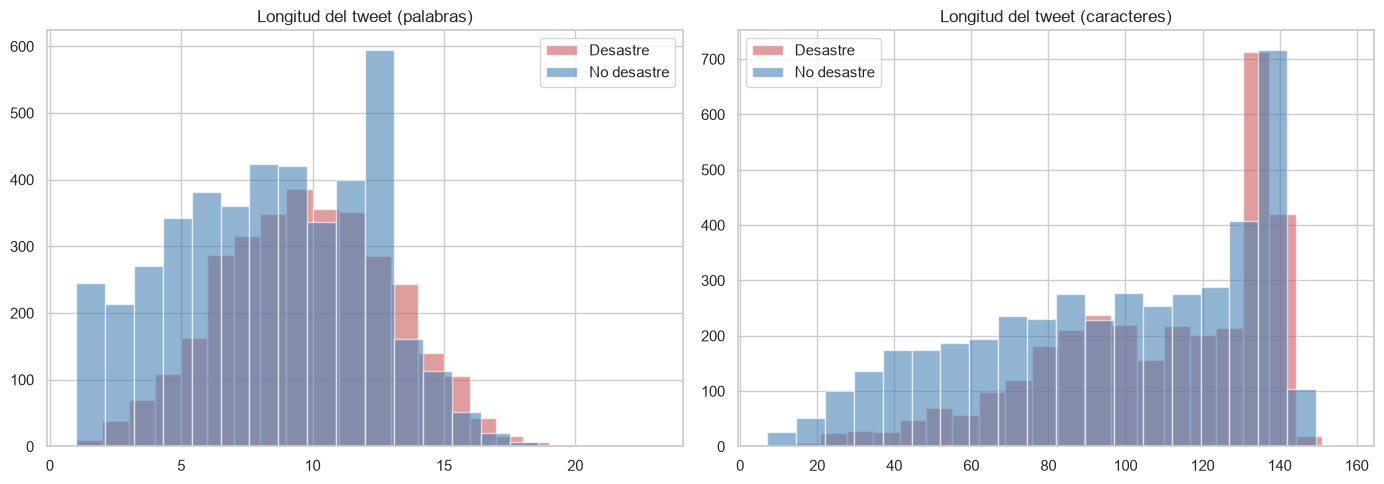

In [60]:
train['longitud_palabras'] = train['text_clean'].apply(lambda t: len(t.split()))
train['longitud_caracteres'] = train['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

train[train['target']==1]['longitud_palabras'].hist(alpha=0.6, label='Desastre', bins=20, ax=axes[0], color='indianred')
train[train['target']==0]['longitud_palabras'].hist(alpha=0.6, label='No desastre', bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('Longitud del tweet (palabras)')
axes[0].legend()

train[train['target']==1]['longitud_caracteres'].hist(alpha=0.6, label='Desastre', bins=20, ax=axes[1], color='indianred')
train[train['target']==0]['longitud_caracteres'].hist(alpha=0.6, label='No desastre', bins=20, ax=axes[1], color='steelblue')
axes[1].set_title('Longitud del tweet (caracteres)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.7 ¿Los tweets con keyword no nulo se asocian más a desastre real?

In [61]:
train['tiene_keyword'] = train['keyword'].notna()
print(pd.crosstab(train['tiene_keyword'], train['target'], normalize='index'))

target                0         1
tiene_keyword                    
False          0.311475  0.688525
True           0.572431  0.427569


### 5.8 Top keywords más asociadas a desastre real vs no

In [62]:
top_keywords_desastre = train[train['target']==1]['keyword'].value_counts().head(10)
top_keywords_no_desastre = train[train['target']==0]['keyword'].value_counts().head(10)

print("Top 10 keywords en tweets de DESASTRE:")
print(top_keywords_desastre)
print("\nTop 10 keywords en tweets NO desastre:")
print(top_keywords_no_desastre)

Top 10 keywords en tweets de DESASTRE:
keyword
derailment           39
outbreak             39
wreckage             39
debris               37
oil%20spill          37
typhoon              37
rescuers             32
suicide%20bomb       32
suicide%20bombing    32
evacuated            32
Name: count, dtype: int64

Top 10 keywords en tweets NO desastre:
keyword
body%20bags    40
armageddon     37
harm           37
deluge         36
ruin           36
wrecked        36
explode        35
fear           35
twister        35
siren          35
Name: count, dtype: int64


La siguiente parte se encuentra en el archivo de lab5_modelos_clasificación